<a href="https://colab.research.google.com/github/Parniika2/Deep-Learning/blob/main/03_MNIST_CNN_Handwritten_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 3: Handwritten Digit Recognition using CNN (MNIST)

## Objective
To build and train a Convolutional Neural Network (CNN) using TensorFlow/Keras for handwritten digit recognition on the MNIST dataset.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 126s 133ms/step - accuracy: 0.9567 - loss: 0.1433
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 137s 128ms/step - accuracy: 0.9864 - loss: 0.0434
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 143s 130ms/step - accuracy: 0.9915 - loss: 0.0269
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 120s 128ms/step - accuracy: 0.9940 - loss: 0.0188
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 123s 131ms/step - accuracy: 0.9956 - loss: 0.0144
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9905 - loss: 0.0321
Test Accuracy: 0.9904999732971191
Test Loss: 0.032070666551589966
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


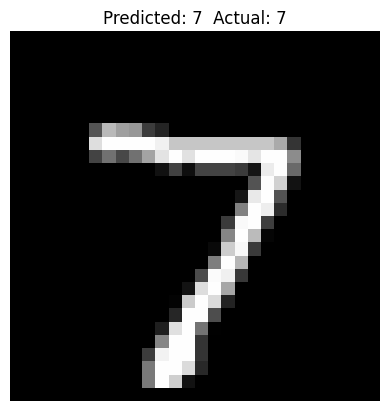

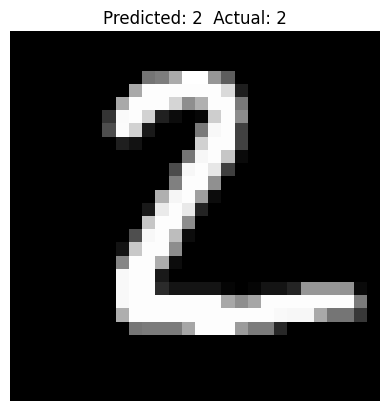

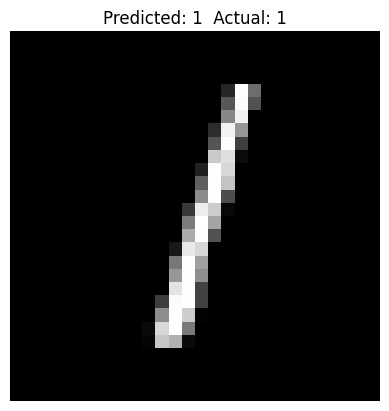

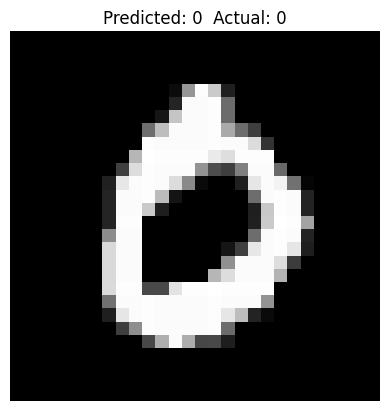

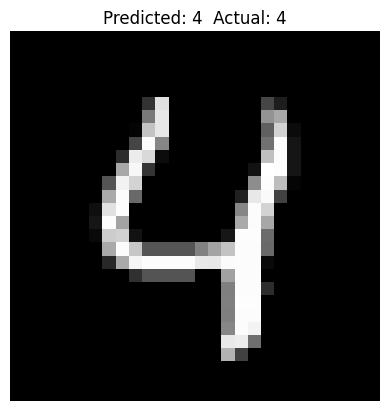

In [1]:
# Handwritten Digit Recognition using CNN (MNIST)
# exp 3
# Import libraries

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Step 1: Load MNIST dataset

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Step 2: Normalize pixel values (0–255 → 0–1)

x_train = x_train / 255.0
x_test = x_test / 255.0

# Step 3: Reshape data to include channel dimension

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Step 4: Convert labels to categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Step 5: Build CNN model

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Step 6: Compile model

model.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

# Step 7: Train model

model.fit(x_train, y_train, epochs=5, batch_size=64)

# Step 8: Evaluate model

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

# Step 9: Make predictions

predictions = model.predict(x_test)

# Step 10: Display first 5 test images with predictions

for i in range(5):
  plt.imshow(x_test[i].reshape(28,28), cmap='gray')
  plt.title("Predicted: " + str(predictions[i].argmax()) +
            "  Actual: " + str(y_test[i].argmax()))
  plt.axis('off')
  plt.show()
